# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data')
!ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("*.json"))


# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']

index.html			    subj_5eee77689e63ac330681ffe9.json
old_cv_data			    subj_5f2f2e85c14511319b159fff.json
subj_55b2d3f2fdf99b525bc839aa.json  subj_6022d09061828908fbf92853.json
subj_58a95ef0bb9e0f0001acaa8b.json  subj_61603594da220b1a4dbac2ec.json
subj_5a8185b8aa46dd00016b80d6.json  subj_6229ea04db7c5f22b18c678d.json
subj_5b5e0e86902ad10001cfcc59.json  subj_62fbe437b039b379e13a184b.json
subj_5c26ac6163e1d8000103824f.json  subj_6385176faa1fd90c21cd7cb0.json
subj_5c351b21d4ae620001d3ee01.json  subj_639b9b047b98a3d09a77a6c6.json
subj_5ca1241ffd16b8000173e4ee.json  subj_63d5021468a31efc02740c1e.json
subj_5d11067c2016b10019c043e9.json  subj_640105daa923d3f5f2669039.json
subj_5dd05d80b2204f1487f7812c.json  subj_64087b8444f656e9e2b74446.json
subj_5e2c8f69cad44b2bc5ce9a34.json  subj_6472ec9d6898fb5a55efa348.json
subj_5e380457679e67000c56b02f.json  subj_64e871eb5d4b2bd9ce50f82b.json
subj_5e3a0494852c30225cf95713.json  subj_undefined.json
subj_5ea1dc176205ad0c7c941ca1.json


In [3]:
eg_part_data = json.load(open(human_fnames[0], 'r'))
eg_df = pd.DataFrame.from_records(eg_part_data)

In [4]:
## Get all subject data into one df for analysis
def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df


dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
expmnt_trial_str = "dictionary-text"

subj_5a8185b8aa46dd00016b80d6 success True
subj_63d5021468a31efc02740c1e success True
subj_5d11067c2016b10019c043e9 success True
subj_64087b8444f656e9e2b74446 success True
subj_5ca1241ffd16b8000173e4ee success True
subj_5ea1dc176205ad0c7c941ca1 success True
subj_5e3a0494852c30225cf95713 success True
subj_61603594da220b1a4dbac2ec success True
subj_64e871eb5d4b2bd9ce50f82b success True
Unterminated string starting at: line 1 column 71816 (char 71815)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_62fbe437b039b379e13a184b.json
subj_5dd05d80b2204f1487f7812c success True
subj_6022d09061828908fbf92853 success True
subj_6385176faa1fd90c21cd7cb0 success True
subj_639b9b047b98a3d09a77a6c6 success True
Unterminated string starting at: line 1 column 454384 (char 454383)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_5e380457679e67000c56b02f.json
subj_6229ea04db7c5f22b18c678d success True
subj_5c351b21d4ae620001d3ee01 succes

In [5]:
results_df.head()

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,stim_type,hc_answer,hc_correct,response_str,catch_trial,correct_response,trial_num,correct,n_correct,n_incorrect
0,True,False,[],[],[],preload,0,219,0.0-0.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,instructions,1,52934,0.0-1.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,63661,0.0-3.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,78615,0.0-4.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,86654,0.0-5.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# results_df[results_df.trial_type == "dictionary-text"] # only with rresponses 

In [7]:
results_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect'],
      dtype='object')

In [8]:
results_df = results_df[results_df.hc_passed == True]

In [9]:
stim_cond_map

NameError: name 'stim_cond_map' is not defined

In [10]:
## Map wav str to stim_type using condition dict
import re

map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}
# stim_cond_map



def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition


results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

In [11]:
results_df.head()

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,hc_correct,response_str,catch_trial,correct_response,trial_num,correct,n_correct,n_incorrect,snr,condition
0,True,False,[],[],[],preload,0,219,0.0-0.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
1,NaN,NaN,NaN,NaN,NaN,instructions,1,52934,0.0-1.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,63661,0.0-3.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,78615,0.0-4.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,86654,0.0-5.0,cocktail_party_word_recognition/data/subj_5a81...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None


In [12]:
results_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'snr', 'condition'],
      dtype='object')

In [13]:
results_df.trial_type.unique()

array(['preload', 'instructions', 'survey-multi-choice', 'survey-text',
       'html-button-response', 'audio-button-response',
       'audio-keyboard-response', 'dictionary-text',
       'html-keyboard-response'], dtype=object)

In [14]:
trial_results = results_df[results_df.trial_type == "dictionary-text"]

In [15]:
trial_results.condition.unique()

array(['background_cv08talkerbabble', '4-talker',
       'background_issnstationary', 'background_issnfestenplomp',
       '1-talker', 'catch_trial', 'background_audioset',
       'background_musdb18hq', 'background_ieeeaaspcasa', 'SILENCE'],
      dtype=object)

In [16]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
catch_trial_particiapnt_performance

/tmp/ipykernel_40079/798094779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


id_subject
55b2d3f2fdf99b525bc839aa    0.750000
58a95ef0bb9e0f0001acaa8b    0.000000
5a8185b8aa46dd00016b80d6    0.916667
5b5e0e86902ad10001cfcc59    1.000000
5c26ac6163e1d8000103824f    1.000000
5ca1241ffd16b8000173e4ee    0.000000
5dd05d80b2204f1487f7812c    1.000000
5e2c8f69cad44b2bc5ce9a34    1.000000
5ea1dc176205ad0c7c941ca1    1.000000
5f2f2e85c14511319b159fff    1.000000
6022d09061828908fbf92853    0.545455
6229ea04db7c5f22b18c678d    1.000000
639b9b047b98a3d09a77a6c6    0.000000
640105daa923d3f5f2669039    1.000000
64087b8444f656e9e2b74446    0.500000
Name: accuracy, dtype: float64

In [40]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 12/12].index
print("N good participants ", len(good_participants))

good_results = results_df[results_df.id_subject.isin(good_participants)]

N total participants  15
N good participants  8


In [41]:
good_results.condition.value_counts()

background_issnstationary      494
background_musdb18hq           486
background_audioset            486
background_cv08talkerbabble    482
background_issnfestenplomp     478
background_ieeeaaspcasa        474
1-talker                       462
4-talker                       404
catch_trial                    126
SILENCE                         42
Name: condition, dtype: int64

In [42]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


In [43]:
# get trial data excluding catch trials 
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .correct
                     .agg(["mean"])
                     .reset_index())



In [44]:
part_summary_df

,snr,id_subject,condition,mean
0,-9,5b5e0e86902ad10001cfcc59,1-talker,1.000000
1,-9,5b5e0e86902ad10001cfcc59,background_audioset,0.000000
2,-9,5b5e0e86902ad10001cfcc59,background_ieeeaaspcasa,0.000000
3,-9,5b5e0e86902ad10001cfcc59,background_issnstationary,0.000000
4,-9,5c26ac6163e1d8000103824f,1-talker,0.300000
...,...,...,...,...
306,inf,6229ea04db7c5f22b18c678d,catch_trial,1.000000
307,inf,640105daa923d3f5f2669039,catch_trial,1.000000
308,inf,5e2c8f69cad44b2bc5ce9a34,SILENCE,1.000000
309,inf,5ea1dc176205ad0c7c941ca1,SILENCE,0.666667


In [45]:
# part_summary_df = part_summary_df[part_summary_df.jspsych_id != 'vgbrx2o3mb']

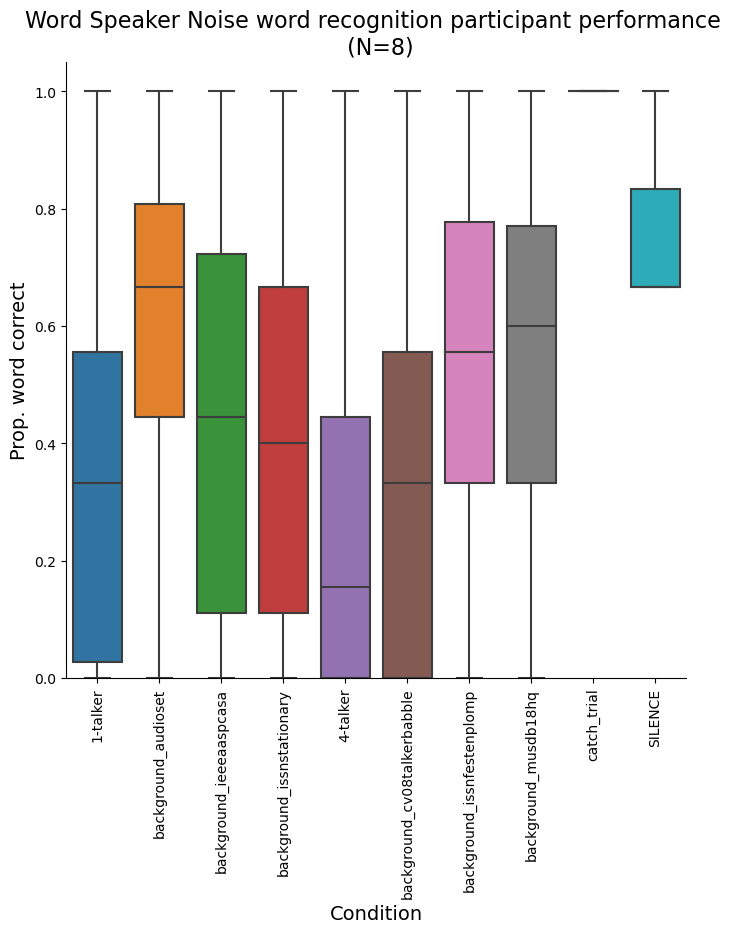

In [46]:
fontsize=14
n_participants = part_summary_df.id_subject.unique().shape[0]
fig, axs = plt.subplots(1, figsize=(8,8))

conds = part_summary_df.condition.unique()# order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.boxplot( data=part_summary_df, x="condition",
                   y="mean",  #error='sem',
                   order=conds,
                  #capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,1.05)
p.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
p.set_xlabel("Condition",fontsize=fontsize)
p.set_ylabel("Prop. word correct", fontsize=fontsize)


p.set_xticklabels(labels=conds, rotation=90, size=10);



In [52]:
to_plot.snr.unique()

array([-9, -6, -3, 0, 3, 'inf'], dtype=object)

Text(63.61244791666667, 0.5, 'Prop. word correct')

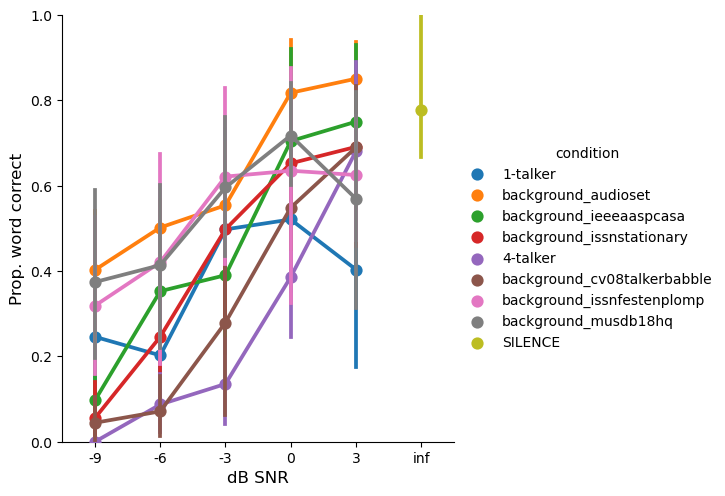

In [67]:
fontsize=14


n_participants = part_summary_df.id_subject.unique().shape[0]
# fig, axs = plt.subplots(1, figsize=(8,8))

to_plot = part_summary_df[part_summary_df.condition != 'catch_trial'].reset_index()
conds = to_plot.condition.unique()
p = sns.catplot( kind='point',data=to_plot, x="snr",
                   y="mean",  hue='condition', errorbar=('sem', 1), 
                #    linestyles="None",
                #    palette=["tab:blue", "tab:orange", "tab:green"],
                   )

sns.despine()
plt.ylim(0,1)
# axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
#                  fontsize=fontsize + 2)
p.ax.set_xlabel("dB SNR",fontsize=12)
p.ax.set_ylabel("Prop. word correct", fontsize=12)

# p.set_xticklabels(labels=conds, rotation=0, size=fontsize)



In [109]:
part_summary_df.condition.value_counts()

background_audioset            25
1-talker                       24
background_ieeeaaspcasa        24
background_issnstationary      23
background_musdb18hq           23
background_cv08talkerbabble    22
background_issnfestenplomp     22
4-talker                       19
catch_trial                     5
Name: condition, dtype: int64